# Sound2Tool — klasyfikacja rodzin instrumentów muzycznych

*Jakub Orchowski, Franciszek Przybyłowski*

Notebook implementuje automatyczną klasyfikację rodziny instrumentu muzycznego na podstawie czterosekundowego nagrania pojedynczej nuty, z wykorzystaniem uczenia głębokiego na melspektrogramach.

## 1. Streszczenie

Projekt Sound2Tool obejmuje budowę systemu automatycznej klasyfikacji rodziny instrumentu muzycznego na podstawie czterosekundowego nagrania pojedynczej nuty. Wykorzystano zbiór danych NSynth (Google Magenta), liczący ponad trzysta tysięcy nagrań przypisanych do jedenastu klas. Nagrania przekształcono w melspektrogramy i porównano trzy podejścia: klasyfikator Random Forest na cechach MFCC, splotową sieć neuronową CNN oraz hybrydę CNN i LSTM uwzględniającą zależności czasowe w obrębie nuty. Na zbiorze testowym najlepszy wynik, 78,7% dokładności, uzyskał model CNN+LSTM, wyraźnie przewyższając baseline RF (57,5% na zbiorze walidacyjnym) oraz sam CNN (77,7%), co potwierdza skuteczność uczenia głębokiego w rozpoznawaniu barwy instrumentów.

## 2. Wstęp

Automatyczne rozpoznawanie instrumentów muzycznych na podstawie nagrania audio jest jednym z klasycznych zadań dziedziny Music Information Retrieval (MIR). Znajduje ono zastosowanie m.in. w wyszukiwaniu utworów po brzmieniu, automatycznej transkrypcji nut, tagowaniu i organizacji bibliotek sampli, rekomendacji muzycznej oraz w narzędziach edukacyjnych wspierających naukę gry. Zadanie to jest utrudnione przez dużą zmienność barwy (timbre) zależną od techniki gry, sposobu wzbudzenia dźwięku i warunków nagrania, a w muzyce polifonicznej dodatkowo przez nakładanie się brzmień wielu instrumentów.

W ostatniej dekadzie dominującym podejściem do tego problemu stało się łączenie reprezentacji czasowo-częstotliwościowych sygnału audio — takich jak melspektrogram — z konwolucyjnymi sieciami neuronowymi (CNN) zaczerpniętymi z analizy obrazów. Klasyfikację dźwięku traktuje się wtedy jak klasyfikację dwuwymiarowej mapy energii sygnału w czasie i częstotliwości, co pozwala sieci automatycznie uczyć się cech istotnych dla rozpoznania instrumentu bez ręcznego projektowania deskryptorów akustycznych.

Niniejszy notebook implementuje taki system w ramach projektu Sound2Tool. Prezentuje pełny potok pracy z danymi audio: od pobrania i przygotowania zbioru NSynth, przez ekstrakcję cech i ich efektywne cache'owanie, po trenowanie, ewaluację i interaktywną klasyfikację nowych nagrań. Sprawozdanie ułożone jest w dziewięciu sekcjach odpowiadających kolejnym etapom eksperymentu; podsekcje rozsiane są przy odpowiadającym im kodzie, dlatego numeracja 7.x pojawia się w kilku miejscach notebooka.

## 3. Kontekst i cel projektu

Sformułowany problem jest zadaniem klasyfikacji wieloklasowej: dla danego czterosekundowego nagrania pojedynczej nuty (16 kHz, mono) należy przewidzieć, do której z jedenastu rodzin instrumentów ono należy — bass, brass, flute, guitar, keyboard, mallet, organ, reed, string, synth_lead, vocal. Operujemy na nagraniach monofonicznych i pojedynczych nutach, co odróżnia to zadanie od trudniejszego problemu rozpoznawania instrumentu dominującego w nagraniu polifonicznym, którym zajmuje się część przywołanej w sekcji 4 literatury.

Celem projektu jest zbudowanie i porównanie trzech podejść o rosnącej złożoności: klasycznego klasyfikatora uczenia maszynowego jako punktu odniesienia (baseline), splotowej sieci neuronowej operującej na melspektrogramach oraz modelu hybrydowego CNN+LSTM, który dodatkowo modeluje zależności czasowe w obrębie przebiegu nuty (fazy atak, podtrzymanie, wybrzmienie).

Równie istotnym celem, z inżynierskiego punktu widzenia, jest zbudowanie kompletnego i wydajnego potoku: pobrania danych, ekstrakcji i cache'owania cech akustycznych, trenowania z regularyzacją, ewaluacji na zbiorze testowym oraz prostego interfejsu pozwalającego sklasyfikować dowolny plik audio bez ponownego trenowania modelu.

## 4. Literatura

Zbiór NSynth wprowadzili Engel i in. (2017) w pracy nad autoenkoderem WaveNet, udostępniając ponad 300 tys. nagrań pojedynczych nut jako benchmark dla uczenia maszynowego w domenie audio. Zastosowanie CNN na melspektrogramach do rozpoznawania instrumentów ustalili Han, Kim i Lee (2017), wykazując przewagę tego podejścia nad metodami opartymi na cechach spektralnych i klasyfikatorach SVM. Chen, Ghobakhlou i Narayanan (2024) porównali sześć reprezentacji widmowych na tym samym zbiorze NSynth i dziesięciu rodzinach, potwierdzając — z wykorzystaniem map istotności (Integrated Gradients) — że melspektrogram i MFCC należą do najbardziej informatywnych reprezentacji. Senatori i in. (2025) zastosowali ten sam schemat porównania baseline'u ML (regresja logistyczna, kNN, Random Forest) z CNN, a Akter i in. (2025) uzasadnili teoretycznie architektury hybrydowe CNN+LSTM w klasyfikacji dźwięku, wykazując ich przewagę nad samodzielnym CNN i LSTM. Wspólny wniosek przywołanej literatury: dla nagrań izolowanych o ograniczonej zmienności akustycznej modele oparte na melspektrogramie i CNN osiągają wysoką dokładność, a głównym wyzwaniem pozostaje niezbalansowanie klas oraz mylenie instrumentów o zbliżonej barwie — obie obserwacje znajdują potwierdzenie w wynikach niniejszego projektu (sekcja 8).

### Środowisko i biblioteki

Potok zaimplementowano w Pythonie z wykorzystaniem ekosystemu PyTorch. Do przetwarzania audio użyto `librosa` oraz `torchaudio` (GPU-akcelerowana ekstrakcja melspektrogramów), do trenowania sieci — PyTorch z CUDA, a do klasyfikatora bazowego — scikit-learn. Wizualizacje tworzone są matplotlibem, a interaktywny interfejs oparto na ipywidgets. Poniższa komórka importuje wszystkie zależności, ustala ziarno losowości (42) dla powtarzalności eksperymentu oraz wykrywa dostępne urządzenie (GPU/CPU).

In [1]:
import json
import os
import tarfile
from concurrent.futures import ThreadPoolExecutor
from functools import partial
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
from pypdl import Pypdl
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
torch.backends.cudnn.benchmark = True

print(f"Using device: {device}")

Using device: cuda


### Konfiguracja i hiperparametry

Wszystkie parametry potoku zebrano w jednym miejscu, co ułatwia powtarzalne eksperymenty. Częstotliwość próbkowania 16 kHz i długość nuty 4 s determinują rozmiar wejścia; parametry STFT (`n_fft=1024`, `hop_length=512`, `n_mels=128`) kształtują melspektrogram. Hiperparametry treningu: batch 256, 30 epok, współczynnik uczenia 1e-3, cierpliwość early stopping 7. Osobny `GPU_BATCH_SIZE=512` kontroluje rozmiar partii przy ekstrakcji cech na karcie graficznej, a liczba workerów DataLoadera ograniczona jest do 16. Zdefiniowano też listę 11 rodzin instrumentów oraz ścieżki do danych i katalogu cache.

In [2]:
SAMPLE_RATE = 16000
NOTE_DURATION = 4.0
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 1024
BATCH_SIZE = 256
GPU_BATCH_SIZE = 512
NUM_WORKERS = min(os.cpu_count() or 4, 16)
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
PATIENCE = 7

INSTRUMENT_FAMILIES = [
    "bass",
    "brass",
    "flute",
    "guitar",
    "keyboard",
    "mallet",
    "organ",
    "reed",
    "string",
    "synth_lead",
    "vocal",
]

DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "nsynth-train"
VALID_DIR = DATA_DIR / "nsynth-valid"
TEST_DIR = DATA_DIR / "nsynth-test"
CACHE_DIR = DATA_DIR / "cache"

BASE_URL = "http://download.magenta.tensorflow.org/datasets/nsynth/"

print(f"Training for {NUM_EPOCHS} epochs with batch size {BATCH_SIZE}")

Training for 30 epochs with batch size 256


## 5. Opis danych

### 5.1 Pozyskanie i podział zbioru danych

Projekt wykorzystuje zbiór NSynth udostępniony przez Google Magenta, rozdzielony na trzy ustandaryzowane podzbiory:

| Podzbiór | Liczba nagrań | Przeznaczenie |
|---|---|---|
| Train (trening) | 289 205 | uczenie modeli |
| Valid (walidacja) | 12 678 | dobór hiperparametrów, early stopping |
| Test | 4 096 | ostateczna, nieobciążona ewaluacja |

Każde nagranie to plik WAV o długości 4 s, próbkowany 16 kHz, reprezentujący pojedynczą zagraną i wybrzmiewającą nutę. Archiwa (rzędu kilku GB każde) pobierane są jednorazowo i dekompresowane; przy kolejnych uruchomieniach krok ten jest pomijany, jeśli dane są już obecne na dysku.

In [3]:
def download_and_extract(split: str, data_dir: Path):
    """Download and extract an NSynth split (train/valid/test)."""
    filename = f"nsynth-{split}.jsonwav.tar.gz"
    tar_path = data_dir / filename
    extract_dir = data_dir / f"nsynth-{split}"

    if extract_dir.exists() and (extract_dir / "examples.json").exists():
        print(f"{split} already extracted, skipping.")
        return

    data_dir.mkdir(parents=True, exist_ok=True)

    if not tar_path.exists():
        url = BASE_URL + filename
        print(f"Downloading {split}...")
        dl = Pypdl()
        dl.start(
            url=url,
            file_path=str(tar_path),
            segments=10,
            display=True,
            multisegment=True,
            overwrite=False,
        )
    else:
        print(f"Tar file already exists: {tar_path}")

    print(f"Extracting {tar_path} ...")
    try:
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall(path=data_dir, filter="data")
        tar_path.unlink()
        print(f"Done: {extract_dir}")
    except Exception as e:
        print(f"Extraction failed: {e}")
        if extract_dir.exists():
            import shutil
            shutil.rmtree(extract_dir)
        print("Partial extraction removed. Run again to retry.")


for split in ["train", "valid", "test"]:
    download_and_extract(split, DATA_DIR)

train already extracted, skipping.
valid already extracted, skipping.
test already extracted, skipping.


### 5.2 Metadane i rodziny instrumentów

Każdy przykład opisany jest metadanymi: unikalnym identyfikatorem `note_str`, etykietą rodziny `instrument_family_str`, wysokością w skali MIDI (`pitch`, zakres 21–108) oraz głośnością uderzenia (`velocity`: 25, 50, 75, 100, 127). Zbiór obejmuje jedenaście rodzin instrumentów — akustycznych, elektronicznych i w pełni syntezowanych:

| Rodzina | Przykładowe instrumenty |
|---|---|
| bass | gitara basowa, bas syntetyczny |
| brass | trąbka, puzon |
| flute | flet i pokrewne dęte drewniane |
| guitar | gitary akustyczne i elektryczne |
| keyboard | fortepian, pianino elektryczne, klawikord |
| mallet | marimba, ksylofon, wibrafon |
| organ | organy piszczałkowe, Hammond |
| reed | saksofon, klarnet, obój |
| string | skrzypce, wiolonczela, altówka |
| synth_lead | syntezatorowe brzmienia prowadzące |
| vocal | ludzki głos |

In [4]:
def load_nsynth_json(split_dir: Path) -> pd.DataFrame:
    """Load NSynth metadata from examples.json into a DataFrame."""
    json_path = split_dir / "examples.json"
    with open(json_path) as f:
        data = json.load(f)

    rows = []
    for note_str, meta in data.items():
        rows.append(
            {
                "note_str": note_str,
                "instrument_family": meta["instrument_family"],
                "instrument_family_str": meta["instrument_family_str"],
                "instrument_source": meta["instrument_source"],
                "instrument_source_str": meta["instrument_source_str"],
                "instrument_str": meta["instrument_str"],
                "pitch": meta["pitch"],
                "velocity": meta["velocity"],
            }
        )

    return pd.DataFrame(rows)


def load_audio(
    note_str: str, split_dir: Path, target_len: int = int(SAMPLE_RATE * NOTE_DURATION)
) -> np.ndarray:
    """Load and preprocess audio file with loudness normalization."""
    wav_path = split_dir / "audio" / f"{note_str}.wav"
    audio, _ = soundfile.read(wav_path, dtype="float32", frames=target_len)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    rms = np.sqrt(np.mean(audio ** 2))
    if rms > 0:
        audio = audio / rms * 0.1
    return audio.astype(np.float32)


def extract_mel_spectrogram(
    audio: np.ndarray,
    device: torch.device,
    mel_transform: torchaudio.transforms.MelSpectrogram | None = None,
) -> np.ndarray:
    """Extract log-mel spectrogram from audio waveform using GPU."""
    if mel_transform is None:
        mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_mels=N_MELS,
            hop_length=HOP_LENGTH,
            n_fft=N_FFT,
        ).to(device)

    audio_tensor = torch.from_numpy(audio).float().unsqueeze(0).to(device)
    mel = mel_transform(audio_tensor)
    mel_db = 10 * torch.log10(mel.clamp(min=1e-10) / mel.max())
    return mel_db.squeeze(0).cpu().numpy()


df_train = load_nsynth_json(TRAIN_DIR)
df_valid = load_nsynth_json(VALID_DIR)
df_test = load_nsynth_json(TEST_DIR)

print(f"Train: {len(df_train):,} samples")
print(f"Valid: {len(df_valid):,} samples")
print(f"Test:  {len(df_test):,} samples")
print(f"\nSample metadata:")
df_train.head()

Train: 289,205 samples
Valid: 12,678 samples
Test:  4,096 samples

Sample metadata:


,note_str,instrument_family,instrument_family_str,instrument_source,instrument_source_str,instrument_str,pitch,velocity
0,guitar_acoustic_001-082-050,3,guitar,0,acoustic,guitar_acoustic_001,82,50
1,bass_synthetic_120-108-050,0,bass,2,synthetic,bass_synthetic_120,108,50
2,organ_electronic_120-050-127,6,organ,1,electronic,organ_electronic_120,50,127
3,guitar_electronic_021-026-025,3,guitar,1,electronic,guitar_electronic_021,26,25
4,organ_electronic_011-079-075,6,organ,1,electronic,organ_electronic_011,79,75


### 5.3 Rozkład klas (Rys. 1)

Rozkład klas, pokazany na poniższym wykresie, jest umiarkowanie niezbalansowany: rodziny keyboard i bass są reprezentowane najliczniej, natomiast flute i vocal — najmniej licznie.

Istotnym ograniczeniem zbioru jest fakt, że klasa `synth_lead`, obecna w zbiorze treningowym (5 501 przykładów), nie występuje wcale w podzbiorach valid i test (0 przykładów). W konsekwencji żaden z modeli nie może zostać oceniony pod względem rozpoznawania tej klasy — zerowe wartości precyzji i czułości dla `synth_lead` w raportach klasyfikacji (sekcja 8) są artefaktem struktury zbioru, a nie błędem modelu.

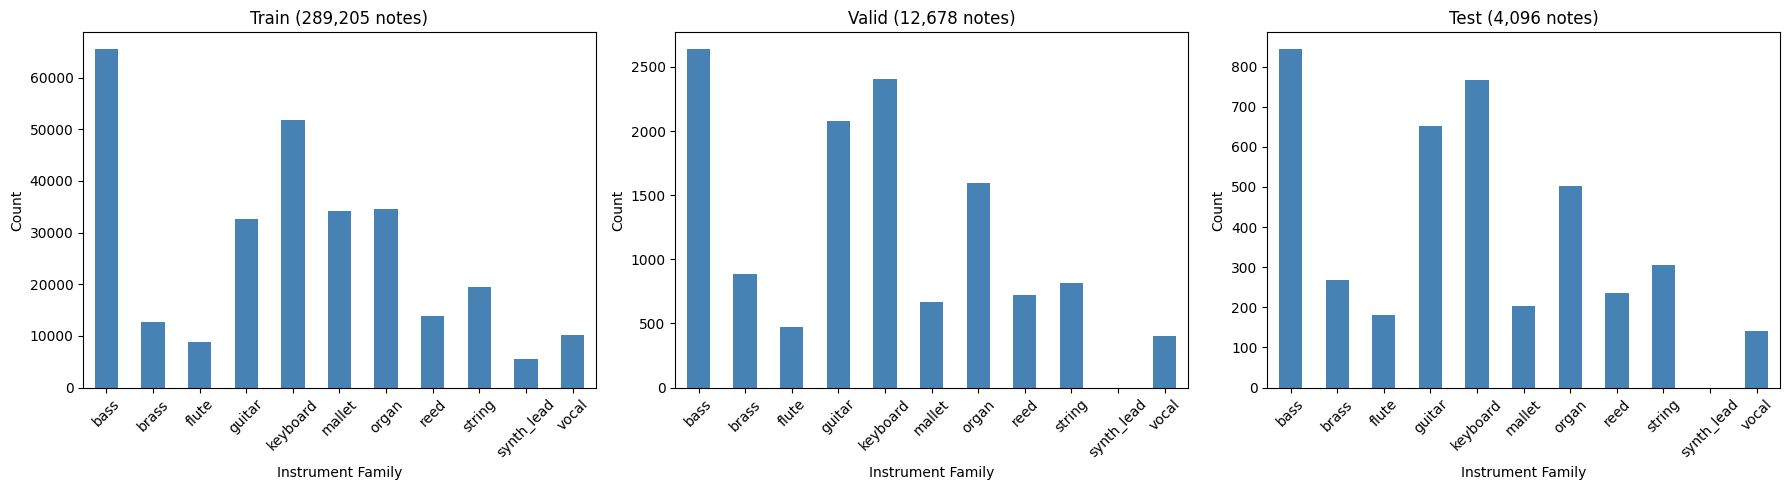


Observations:
- The dataset is relatively balanced across instrument families
- Some families (keyboard, synth_lead) have more samples than others (vocal)
- NOTE: synth_lead has 5,501 training samples but 0 in valid/test sets
  This means it cannot be evaluated - classification_report will show 0 for it


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df, title) in zip(
    axes, [(df_train, "Train"), (df_valid, "Valid"), (df_test, "Test")], strict=True
):
    counts = df["instrument_family_str"].value_counts().reindex(INSTRUMENT_FAMILIES)
    counts.plot.bar(ax=ax, color="steelblue")
    ax.set_title(f"{title} ({len(df):,} notes)")
    ax.set_ylabel("Count")
    ax.set_xlabel("Instrument Family")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- The dataset is relatively balanced across instrument families")
print("- Some families (keyboard, synth_lead) have more samples than others (vocal)")
print("- NOTE: synth_lead has 5,501 training samples but 0 in valid/test sets")
print("  This means it cannot be evaluated - classification_report will show 0 for it")

### 5.4 Reprezentacja melspektrogramowa (Rys. 2)

Surowy przebieg fali akustycznej (64 000 próbek dla 4 s przy 16 kHz) jest trudny do interpretacji i nieefektywny jako wejście sieci konwolucyjnej. Każde nagranie przekształcono zatem w melspektrogram — dwuwymiarową mapę energii sygnału w funkcji czasu i częstotliwości, w której skala częstotliwości jest nieliniowo przeskalowana (skala mel), aby odpowiadała percepcji wysokości dźwięku przez człowieka.

Zastosowano 128 pasm mel, okno FFT 1024 próbki i przeskok (hop length) 512 próbek, co dla nagrania 4-sekundowego daje tensor 1×128×126 (kanał × pasma mel × ramki czasowe) — reprezentację kilkukrotnie mniejszą niż surowy sygnał, przy zachowaniu struktury widmowej istotnej dla klasyfikacji. Poniżej widoczne są wyraźnie różne wzorce widmowe: koncentracja energii w niskich częstotliwościach dla basu oraz ostre, impulsowe ataki dla instrumentów perkusyjnych (mallet). To właśnie te wzorce sieć CNN uczy się rozpoznawać.

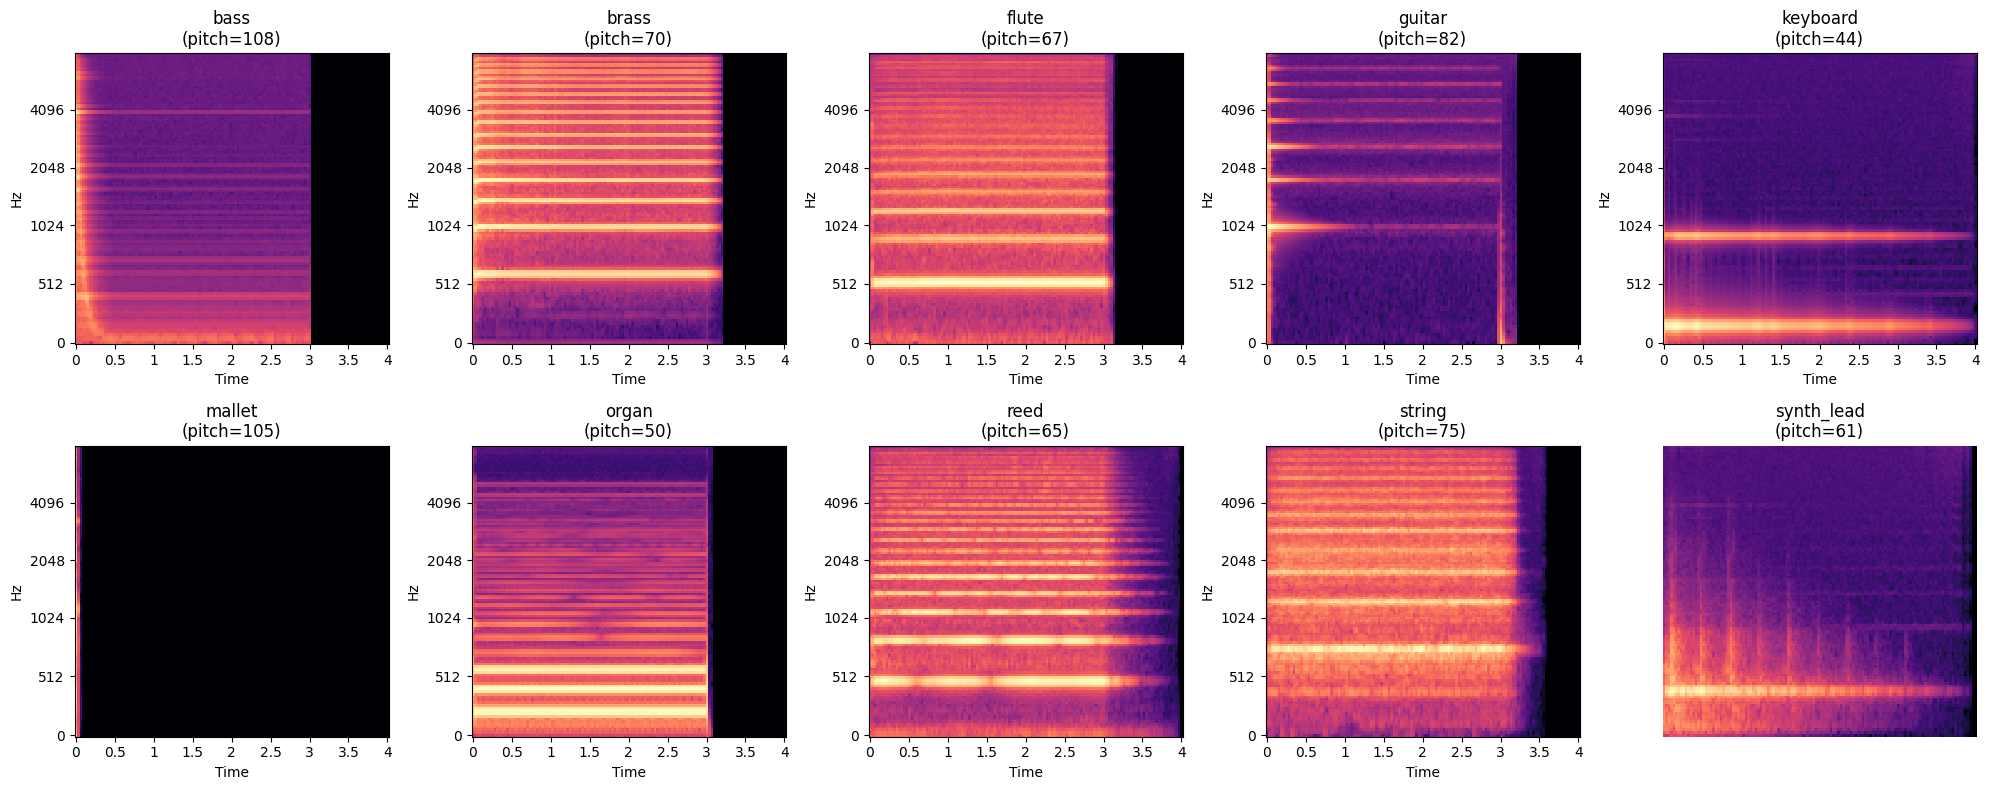


Observations:
- Different instruments have distinct spectral patterns
- Bass instruments show energy in lower frequencies
- Percussive instruments (mallet) show sharp attacks
- These patterns are what the CNN will learn to recognize


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, family in enumerate(INSTRUMENT_FAMILIES[:10]):
    sample = df_train[df_train["instrument_family_str"] == family].iloc[0]
    audio = load_audio(sample["note_str"], TRAIN_DIR)
    mel_db = extract_mel_spectrogram(audio, device)

    librosa.display.specshow(
        mel_db,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        ax=axes[i],
        cmap="magma",
    )
    axes[i].set_title(f"{family}\n(pitch={sample['pitch']})")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Different instruments have distinct spectral patterns")
print("- Bass instruments show energy in lower frequencies")
print("- Percussive instruments (mallet) show sharp attacks")
print("- These patterns are what the CNN will learn to recognize")

## 7. Wdrożenie metod i modelu

Poniższa sekcja opisuje inżynierię potoku — od cache'owania cech i budowy datasetu, przez pętlę uczenia, po inferencję i interaktywny interfejs. Ponieważ sprawozdanie jest rozsiane przy odpowiadającym kodzie, podsekcje 7.x pojawiają się w kolejności komórek notebooka: część z nich (7.1–7.3) poprzedza sekcję 6 opisującą architektury modeli, podsekcja 7.4 znajduje się między sekcją 6 a wynikami, a podsekcje 7.5–7.6 (inferencja) następują po sekcji 8.

### 7.1 Ekstrakcja i cache'owanie cech

Ekstrakcja melspektrogramów dla wszystkich nagrań trwałaby zbyt długo, gdyby wykonywać ją na bieżąco w każdej epoce. Dlatego nagrania wczytywane są równolegle (`ThreadPoolExecutor`), a melspektrogramy obliczane w partiach na GPU i jednorazowo zapisywane do plików NumPy z obsługą memory-mapping (mmap). Takie podejście pozwala wczytywać dane treningowe bez ładowania całej tablicy do pamięci RAM.

Według pomiarów zawartych w notebooku osiąga to przepustowość rzędu 362 batchy na sekundę (ok. 23 tys. próbek/s), skracając czas przygotowania cech z ok. 20 minut (pierwsze uruchomienie) do praktycznie chwili przy kolejnych uruchomieniach, które wczytują gotowy cache. Każdy melspektrogram normalizowany jest logarytmicznie (skala dB) względem własnego maksimum, a audio poddawane normalizacji głośności (RMS do 0,1) dla spójności między nagraniami. Kolejne uruchomienia notebooka pomijają cały krok, jeśli plik cache już istnieje.

In [7]:
def cache_mel_spectrograms(
    df: pd.DataFrame,
    split_dir: Path,
    cache_name: str,
    max_workers: int = NUM_WORKERS,
) -> str:
    """Cache mel spectrograms to NumPy file."""
    cache_path = CACHE_DIR / cache_name
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

    if cache_path.exists():
        print(f"Loading cached spectrograms from {cache_path}")
        return str(cache_path)

    target_len = int(SAMPLE_RATE * NOTE_DURATION)
    note_strs = df["note_str"].tolist()

    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=SAMPLE_RATE,
        n_mels=N_MELS,
        hop_length=HOP_LENGTH,
        n_fft=N_FFT,
    ).to(device)

    load_fn = partial(load_audio, split_dir=split_dir, target_len=target_len)

    shape = (len(note_strs), N_MELS, int(SAMPLE_RATE * NOTE_DURATION) // HOP_LENGTH + 1)

    print(f"Processing {len(note_strs)} files in batches of {GPU_BATCH_SIZE}...")
    specs = np.empty(shape, dtype=np.float32)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        def submit_batch(start_idx):
            batch = note_strs[start_idx : start_idx + GPU_BATCH_SIZE]
            return {executor.submit(load_fn, ns): i for i, ns in enumerate(batch)}, start_idx

        next_batch_info = submit_batch(0)
        for batch_start in tqdm(range(0, len(note_strs), GPU_BATCH_SIZE), desc="Spectrograms"):
            curr_futures, curr_start = next_batch_info
            next_start = batch_start + GPU_BATCH_SIZE
            next_batch_info = (
                submit_batch(next_start) if next_start < len(note_strs) else None
            )

            batch_audio = np.empty((len(curr_futures), target_len), dtype=np.float32)
            for future, idx in curr_futures.items():
                batch_audio[idx] = future.result()
            del curr_futures

            batch_tensor = torch.from_numpy(batch_audio).to(device)
            del batch_audio
            mel = mel_transform(batch_tensor)
            del batch_tensor
            mel_max = mel.reshape(mel.size(0), -1).max(dim=1, keepdim=True)[0].unsqueeze(-1)
            mel_db = 10 * torch.log10(mel.clamp(min=1e-10) / mel_max)
            batch_specs = mel_db.cpu().numpy()
            del mel, mel_max, mel_db

            specs[curr_start : curr_start + batch_specs.shape[0]] = batch_specs
            del batch_specs

    np.save(cache_path, specs)
    print(f"Cached {shape} to {cache_path}")
    return str(cache_path)


print("Extracting and caching mel spectrograms...")
print("This may take 10-20 minutes on first run.\n")

train_cache = cache_mel_spectrograms(df_train, TRAIN_DIR, "mel_train.npy")
valid_cache = cache_mel_spectrograms(df_valid, VALID_DIR, "mel_valid.npy")
test_cache = cache_mel_spectrograms(df_test, TEST_DIR, "mel_test.npy")

print("\nCache files created:")
print(f"  {train_cache}")
print(f"  {valid_cache}")
print(f"  {test_cache}")

Extracting and caching mel spectrograms...
This may take 10-20 minutes on first run.

Loading cached spectrograms from ..\data\cache\mel_train.npy
Loading cached spectrograms from ..\data\cache\mel_valid.npy
Loading cached spectrograms from ..\data\cache\mel_test.npy

Cache files created:
  ..\data\cache\mel_train.npy
  ..\data\cache\mel_valid.npy
  ..\data\cache\mel_test.npy


### 7.2 Kodowanie etykiet

Sieci neuronowe wymagają etykiet liczbowych. Tekstowe nazwy rodzin (bass, guitar, ...) konwertowane są na indeksy 0–10 za pomocą `LabelEncoder` z scikit-learn. Encoder zachowuje mapowanie klas, umożliwiając odtworzenie czytelnej nazwy rodziny z predykcji modelu na etapie inferencji. To samo mapowanie stosowane jest spójnie dla zbiorów treningowego, walidacyjnego i testowego.

In [8]:
le = LabelEncoder()
y_train = le.fit_transform(df_train["instrument_family_str"])
y_valid = le.transform(df_valid["instrument_family_str"])
y_test = le.transform(df_test["instrument_family_str"])

print("Label encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {i}: {label}")
print(f"\nTotal classes: {len(le.classes_)}")

Label encoding:
  0: bass
  1: brass
  2: flute
  3: guitar
  4: keyboard
  5: mallet
  6: organ
  7: reed
  8: string
  9: synth_lead
  10: vocal

Total classes: 11


### 7.3 Dataset, DataLoader i augmentacja

Niestandardowa klasa `NSynthDataset` (PyTorch) otwiera plik cache w trybie mmap i udostępnia kolejne przykłady do DataLoadera, skonfigurowanego z `pin_memory=True` (szybszy transfer CPU→GPU) oraz `num_workers=0`. Wybór ten wynika z obserwacji, że na systemie Windows narzut na tworzenie procesów roboczych przewyższa korzyści z równoległego wczytywania; przy mmap sekwencyjny odczyt jest wystarczająco szybki. Włączono również `torch.backends.cudnn.benchmark=True`, co auto-dostosowuje jądra konwolucyjne do stałego rozmiaru wejścia.

Augmentacja danych wykonywana jest na GPU po przeniesieniu batcha na kartę, aby uniknąć wąskiego gardła na CPU. Funkcja `augment_batch` realizuje maskowanie w pasmach częstotliwości i ramkach czasowych (w stylu SpecAugment) oraz addytywne dodawanie szumu Gaussa — losowo, dla części przykładów w batchu. Operacje te zmuszają model do uczenia się cech niezależnych od lokalnych wzorców widmowych i zapobiegają przeuczeniu. Ponieważ augmentacja odbywa się na tensorze GPU, nie wprowadza ona synchronizacji CPU i nie spowalnia pętli treningowej.

In [9]:
class NSynthDataset(Dataset):
    """PyTorch Dataset for NSynth spectrograms with NumPy mmap backend."""

    def __init__(self, cache_path: str | Path, labels: np.ndarray):
        self._cache_path = str(cache_path)
        self.labels = labels.astype(np.int64)
        self._handle = None

    def _get_handle(self):
        if self._handle is None:
            self._handle = np.load(self._cache_path, mmap_mode="r")
        return self._handle

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        handle = self._get_handle()
        spec = np.asarray(handle[idx])
        return torch.from_numpy(spec.copy()).unsqueeze(0), torch.tensor(self.labels[idx])

    def __del__(self):
        self._handle = None


def augment_batch(specs: torch.Tensor) -> torch.Tensor:
    """Apply random augmentation to a batch of spectrograms on GPU (no CPU sync)."""
    B, C, F, T = specs.shape
    d = specs.device

    freq_range = torch.arange(F, device=d).view(1, 1, F, 1)
    time_range = torch.arange(T, device=d).view(1, 1, 1, T)

    mask = torch.rand(B, device=d) < 0.5
    if mask.any():
        fms = torch.randint(1, 8, (B, 1, 1, 1), device=d)
        fs = torch.randint(0, F, (B, 1, 1, 1), device=d).clamp(max=F - 8)
        freq_kill = (freq_range >= fs) & (freq_range < fs + fms) & mask.view(B, 1, 1, 1)
        specs = specs.masked_fill(freq_kill, 0)

    mask = torch.rand(B, device=d) < 0.5
    if mask.any():
        tms = torch.randint(1, 8, (B, 1, 1, 1), device=d)
        ts = torch.randint(0, T, (B, 1, 1, 1), device=d).clamp(max=T - 8)
        time_kill = (time_range >= ts) & (time_range < ts + tms) & mask.view(B, 1, 1, 1)
        specs = specs.masked_fill(time_kill, 0)

    mask = torch.rand(B, device=d) < 0.3
    if mask.any():
        noise = torch.randn_like(specs) * 0.05
        specs = torch.where(mask.view(B, 1, 1, 1), specs + noise, specs)

    return specs


train_dataset = NSynthDataset(train_cache, y_train)
valid_dataset = NSynthDataset(valid_cache, y_valid)
test_dataset = NSynthDataset(test_cache, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

sample_x, sample_y = next(iter(train_loader))
print(f"Batch shape: {sample_x.shape}")
print(f"  - Batch size: {sample_x.shape[0]}")
print(f"  - Channels: {sample_x.shape[1]} (1 for grayscale spectrogram)")
print(f"  - Mel bands: {sample_x.shape[2]}")
print(f"  - Time frames: {sample_x.shape[3]}")
print(f"\nLabels shape: {sample_y.shape}")

Batch shape: torch.Size([256, 1, 128, 126])
  - Batch size: 256
  - Channels: 1 (1 for grayscale spectrogram)
  - Mel bands: 128
  - Time frames: 126

Labels shape: torch.Size([256])


## 6. Opis użytych metod

### 6.1 Model bazowy: Random Forest na cechach MFCC

Jako punkt odniesienia (baseline) zastosowano klasyczny klasyfikator uczenia maszynowego, niewymagający GPU i pozwalający ocenić, czy modele głębokie wnoszą rzeczywistą wartość dodaną. Z każdego nagrania wyodrębniono 20 współczynników MFCC (Mel-Frequency Cepstral Coefficients), a następnie obliczono ich statystyki — średnią i odchylenie standardowe w czasie — uzyskując wektor 40 cech opisujących barwę dźwięku. Klasyfikator Random Forest (100 drzew) wytrenowano na podzbiorze 50 000 nagrań treningowych, co zapewnia rozsądny czas obliczeń przy zachowaniu reprezentatywności próby. Jeśli model głęboki nie przewyższy istotnie tego baseline'u, będzie to sygnał, że architektura wymaga poprawy.

In [10]:
def extract_mfcc_stats(audio: np.ndarray, sr: int = SAMPLE_RATE, n_mfcc: int = 20) -> np.ndarray:
    """Extract MFCC statistics (mean and std per coefficient)."""
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])


print("Extracting MFCC features for baseline...")
print("Using 50,000 training samples for a fair comparison.\n")

MAX_BASELINE_SAMPLES = 50000
train_subset = df_train.iloc[:MAX_BASELINE_SAMPLES]

def process_mfcc(row):
    return extract_mfcc_stats(load_audio(row["note_str"], TRAIN_DIR))

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    X_train_mfcc = np.array(list(tqdm(
        executor.map(process_mfcc, [row for _, row in train_subset.iterrows()]),
        total=len(train_subset), desc="Train MFCC"
    )))
y_train_subset = y_train[:MAX_BASELINE_SAMPLES]

print(f"\nTraining Random Forest on {X_train_mfcc.shape[0]} samples...")
print(f"Features per sample: {X_train_mfcc.shape[1]}")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_mfcc, y_train_subset)

val_subset = df_valid

def process_mfcc_val(row):
    return extract_mfcc_stats(load_audio(row["note_str"], VALID_DIR))

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    X_val_mfcc = np.array(list(tqdm(
        executor.map(process_mfcc_val, [row for _, row in val_subset.iterrows()]),
        total=len(val_subset), desc="Val MFCC"
    )))
y_val_subset = y_valid

rf_accuracy = rf_model.score(X_val_mfcc, y_val_subset)
print(f"\nBaseline RF accuracy: {rf_accuracy:.2%}")

Extracting MFCC features for baseline...
Using 50,000 training samples for a fair comparison.



Train MFCC:   0%|          | 0/50000 [00:00<?, ?it/s]


Training Random Forest on 50000 samples...
Features per sample: 40


Val MFCC:   0%|          | 0/12678 [00:00<?, ?it/s]


Baseline RF accuracy: 57.49%


### 6.2 Splotowa sieć neuronowa (CNN)

Pierwszy model głęboki to CNN operujący bezpośrednio na melspektrogramie traktowanym jako obraz jednokanałowy. Architektura składa się z czterech bloków konwolucyjnych (Conv2d + BatchNorm + ReLU + Dropout2d + MaxPool) o liczbie filtrów rosnącej 32→64→128→256, zakończonych warstwą AdaptiveAvgPool sprowadzającą mapę cech do 4×4 niezależnie od długości nagrania. Spłaszczony wektor przechodzi przez warstwy w pełni połączone (4096→512→11) z dropoutem 0,5 zapobiegającym przeuczeniu.

```
Input: (1, 128, 126)
  ↓ Conv2d(1→32) + BN + ReLU + Dropout2d + MaxPool
  ↓ Conv2d(32→64) + BN + ReLU + Dropout2d + MaxPool
  ↓ Conv2d(64→128) + BN + ReLU + Dropout2d + MaxPool
  ↓ Conv2d(128→256) + BN + ReLU + Dropout2d + AdaptiveAvgPool(4×4)
  ↓ Flatten → Linear(4096→512) + ReLU + Dropout(0.5)
  → Linear(512→11)
```

BatchNorm stabilizuje trening i pozwala na wyższy współczynnik uczenia, MaxPool dodaje niezmienniczość translacji, a AdaptiveAvgPool gwarantuje stały rozmiar wyjścia niezależnie od długości nagrania. Łączna liczba parametrów: 2 492 107.

In [11]:
class InstrumentCNN(nn.Module):
    """Convolutional neural network for instrument classification on mel spectrograms."""

    def __init__(self, num_classes: int = 11):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)


cnn_model = InstrumentCNN(num_classes=len(INSTRUMENT_FAMILIES)).to(device)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"CNN parameters: {total_params:,}")
print("\nArchitecture:")
print(cnn_model)

CNN parameters: 2,492,107

Architecture:
InstrumentCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.2, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout2d(p=0.2, inplace=False)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): Dropout2d(p=0.2, inplace=False)
    (14): MaxPool2d(kernel_size=2, stride=2, padd

### 6.3 Model hybrydowy CNN+LSTM

Trzeci model rozszerza CNN o jawne modelowanie zależności czasowych. Ten sam ekstraktor konwolucyjny przekształca melspektrogram w sekwencję wektorów cech rozłożonych w czasie, które następnie przetwarza dwuwarstwowa sieć LSTM o rozmiarze stanu skrytego 256. Końcowy stan skryty LSTM trafia do warstw w pełni połączonych (256→128→11).

```
Input: (1, 128, 126)
  ↓ CNN Feature Extractor (4 warstwy konwolucyjne)
  ↓ Reshape: (batch, time_steps, features)
  ↓ LSTM (2 warstwy, hidden_size=256)
  ↓ Końcowy stan skryty
  ↓ Linear(256→128) + ReLU + Dropout(0.5)
  → Linear(128→11)
```

Intencją tego rozszerzenia jest uchwycenie ewolucji nuty w czasie — fazy atak, podtrzymanie i wybrzmienie różnią się charakterystyką widmową, co LSTM może wykorzystać jako dodatkowy sygnał dyskryminujący. Model ma 5 145 803 parametry, czyli ponad dwukrotnie więcej niż CNN, głównie ze względu na warstwy rekurencyjne.

In [12]:
class CNNLSTM(nn.Module):
    """CNN + LSTM for instrument classification with temporal modeling."""

    def __init__(self, num_classes: int = 11, input_shape: tuple = (1, 128, 126)):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.2),
        )
        with torch.no_grad():
            dummy = self.cnn(torch.zeros(1, *input_shape))
            self._seq_len = dummy.size(2)
            lstm_input_size = dummy.size(1) * dummy.size(3)
        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn(x)
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3).reshape(batch_size, self._seq_len, -1)
        _, (hidden, _) = self.lstm(x)
        x = hidden[-1]
        return self.classifier(x)


cnnlstm_model = CNNLSTM(num_classes=len(INSTRUMENT_FAMILIES)).to(device)
total_params = sum(p.numel() for p in cnnlstm_model.parameters())
print(f"CNN+LSTM parameters: {total_params:,}")
print("\nArchitecture:")
print(cnnlstm_model)

CNN+LSTM parameters: 5,145,803

Architecture:
CNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.2, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout2d(p=0.2, inplace=False)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): Dropout2d(p=0.2, inplace=False)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0,

### 6.4 Konfiguracja treningu i metryki ewaluacji

Oba modele głębokie trenowano optymalizatorem Adam z początkowym współczynnikiem uczenia 1e-3, funkcją straty cross-entropy z wygładzaniem etykiet (label smoothing 0,1) oraz harmonogramem `ReduceLROnPlateau`, redukującym współczynnik uczenia dwukrotnie przy braku poprawy dokładności walidacyjnej. Zastosowano wczesne zatrzymanie (early stopping) z cierpliwością 7 epok i maksymalną liczbą 30 epok, przy rozmiarze batcha 256.

Modele oceniano na zbiorze testowym za pomocą dokładności (accuracy), precyzji, czułości (recall) i miary F1 dla każdej klasy, a wzorce błędów analizowano na podstawie macierzy konfuzji. Czas treningu każdego modelu to ok. 10–15 minut na GPU.

In [13]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    num_epochs: int = NUM_EPOCHS,
    patience: int = PATIENCE,
    learning_rate: float = LEARNING_RATE,
) -> tuple[nn.Module, dict]:
    """Train a model with validation and early stopping."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )

    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in tqdm(range(num_epochs), desc="Training"):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            inputs = augment_batch(inputs)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1} Val", leave=False):
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch + 1:2d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.6f}"
            f"{' *' if val_acc == best_val_acc else ''}"
        )

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    print(f"\nBest validation accuracy: {best_val_acc:.4f}")
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    return model, history

### 7.4 Implementacja pętli uczenia

Funkcja `train_model()` realizuje pełną pętlę uczenia z walidacją po każdej epoce, redukcją współczynnika uczenia (`ReduceLROnPlateau` monitorujący dokładność walidacyjną), wczesnym zatrzymaniem oraz zapisem wag najlepszego modelu według dokładności walidacyjnej. Augmentacja aplikowana jest tylko w fazie treningu, po przeniesieniu batcha na GPU. Stan najlepszego modelu klonowany jest na CPU, by zachować go niezależnie od dalszych aktualizacji parametrów.

Po zakończeniu treningu funkcja `evaluate_model()` generuje predykcje na zbiorze testowym w trybie `no_grad`, służące dalszej analizie (raport klasyfikacji, macierz konfuzji). Taka struktura oddziela etap uczenia od ewaluacji i zapewnia, że raportowane metryki pochodzą z modelu o najlepszej generalizacji, a nie z ostatniej epoki. Pętla raportuje po każdej epoce stratę i dokładność dla zbioru treningowego i walidacyjnego oraz aktualny współczynnik uczenia, co ułatwia diagnostykę przeuczenia.

## 8. Wyniki

### 8.1 Trening CNN (Rys. 3)

Model bazowy Random Forest na cechach MFCC osiągnął dokładność 57,49% — wyraźnie powyżej losowego zgadywania (1/11 ≈ 9,1%), lecz znacząco poniżej modeli głębokich, co sugeruje, że uśrednione statystyki MFCC nie wystarczają do pełnego uchwycenia różnic barwy między jedenastoma klasami.

Trening CNN zakończył się wczesnym zatrzymaniem po 16 epokach z najlepszą dokładnością walidacyjną 77,64%. Widoczna na poniższym wykresie rosnąca rozbieżność między dokładnością treningową (przekraczającą 94%) a walidacyjną (ok. 77%) wskazuje na umiarkowane przeuczenie względem zbioru walidacyjnego.

In [14]:
print("=" * 60)
print("Training CNN")
print("=" * 60)

cnn_model = InstrumentCNN(num_classes=len(INSTRUMENT_FAMILIES))
cnn_model, cnn_history = train_model(cnn_model, train_loader, valid_loader)

Training CNN


Training:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1 Train:   0%|          | 0/1130 [00:00<?, ?it/s]

Epoch 1 Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch  1/30 | Train Loss: 1.5547 Acc: 0.5454 | Val Loss: 1.2525 Acc: 0.7183 | LR: 0.001000 *


...

Epoch 15 Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 15/30 | Train Loss: 0.7442 Acc: 0.9420 | Val Loss: 1.1212 Acc: 0.7762 | LR: 0.000250


Epoch 16 Train:   0%|          | 0/1130 [00:00<?, ?it/s]

Epoch 16 Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 16/30 | Train Loss: 0.7414 Acc: 0.9428 | Val Loss: 1.1322 Acc: 0.7716 | LR: 0.000250
Early stopping at epoch 16

Best validation accuracy: 0.7764


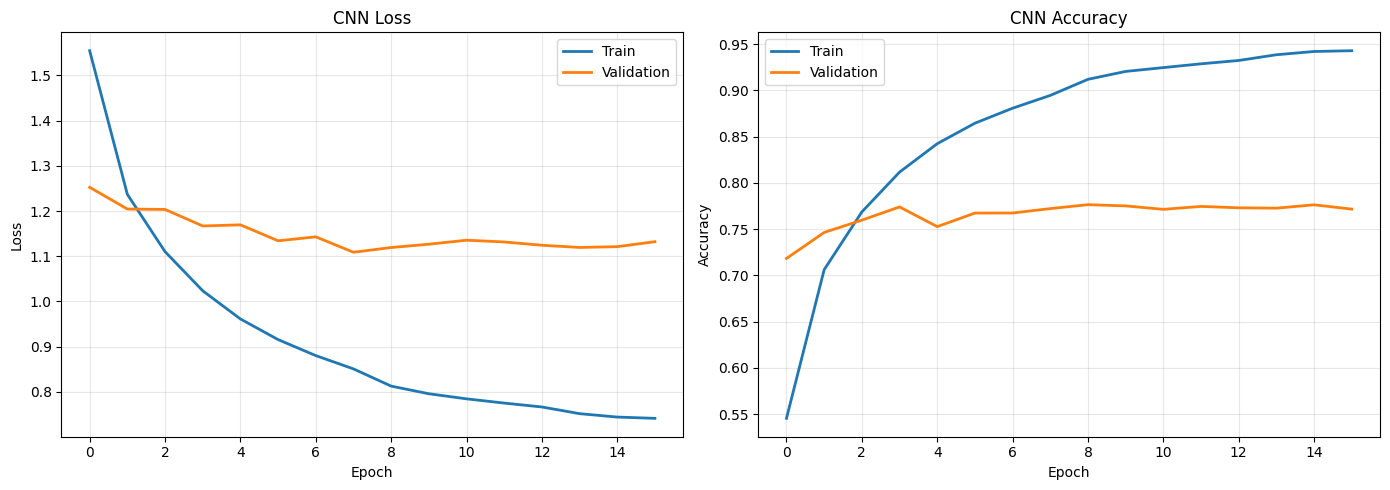


Final CNN validation accuracy: 77.16%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history["train_loss"], label="Train", linewidth=2)
axes[0].plot(cnn_history["val_loss"], label="Validation", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("CNN Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_history["train_acc"], label="Train", linewidth=2)
axes[1].plot(cnn_history["val_acc"], label="Validation", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("CNN Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal CNN validation accuracy: {cnn_history['val_acc'][-1]:.2%}")

### 8.2 Trening CNN+LSTM (Rys. 4)

Model CNN+LSTM trenował się dłużej, zatrzymując się po 20 epokach z najlepszą dokładnością walidacyjną 78,06%. Dokładność treningowa zbliża się do 99%, co przy podobnym poziomie dokładności walidacyjnej jak CNN wskazuje na silniejsze przeuczenie — spodziewany efekt ponaddwukrotnie większej liczby parametrów (5,1 mln wobec 2,5 mln dla CNN).

In [16]:
print("=" * 60)
print("Training CNN+LSTM")
print("=" * 60)

cnnlstm_model = CNNLSTM(num_classes=len(INSTRUMENT_FAMILIES))
cnnlstm_model, cnnlstm_history = train_model(cnnlstm_model, train_loader, valid_loader)

Training CNN+LSTM


Training:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1 Train:   0%|          | 0/1130 [00:00<?, ?it/s]

Epoch 1 Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch  1/30 | Train Loss: 1.3525 Acc: 0.6301 | Val Loss: 1.3051 Acc: 0.6906 | LR: 0.001000 *


...

Epoch 19 Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 19/30 | Train Loss: 0.5592 Acc: 0.9923 | Val Loss: 1.2768 Acc: 0.7705 | LR: 0.000500


Epoch 20 Train:   0%|          | 0/1130 [00:00<?, ?it/s]

Epoch 20 Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 20/30 | Train Loss: 0.5589 Acc: 0.9922 | Val Loss: 1.3088 Acc: 0.7670 | LR: 0.000500
Early stopping at epoch 20

Best validation accuracy: 0.7806


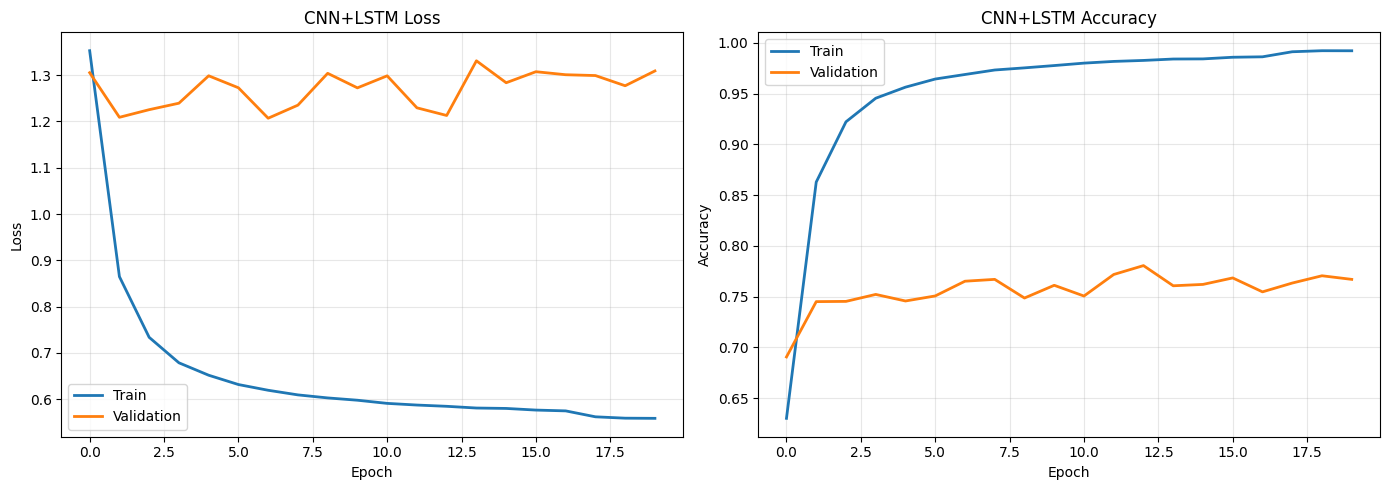


Final CNN+LSTM validation accuracy: 76.70%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnnlstm_history["train_loss"], label="Train", linewidth=2)
axes[0].plot(cnnlstm_history["val_loss"], label="Validation", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("CNN+LSTM Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cnnlstm_history["train_acc"], label="Train", linewidth=2)
axes[1].plot(cnnlstm_history["val_acc"], label="Validation", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("CNN+LSTM Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal CNN+LSTM validation accuracy: {cnnlstm_history['val_acc'][-1]:.2%}")

### 8.3 Ewaluacja na zbiorze testowym

Na zbiorze testowym dokładność ogólna wyniosła 77,7% dla CNN i 78,7% dla CNN+LSTM, ze średnią F1 (macro) na poziomie 0,71 dla obu modeli (wynik zaniżany przez nieobsadzoną klasę `synth_lead` — sekcja 5.3) oraz średnią F1 ważoną liczbą przykładów 0,77 (CNN) i 0,79 (CNN+LSTM). W obu modelach najwyższą precyzję, ale relatywnie niską czułość, uzyskała klasa organ (precyzja 0,99/0,94, czułość 0,61) — model rzadko błędnie przypisuje inne klasy do organu, lecz część rzeczywistych nagrań organu zostaje pomylona z innymi instrumentami. Poniższe raporty klasyfikacji i macierze konfuzji ujawniają szczegółowe wzorce błędów.

In [18]:
@torch.no_grad()
def evaluate_model(model: nn.Module, test_loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    """Evaluate model on test set and return predictions and labels."""
    model.eval()
    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(test_loader, desc="Evaluating"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


print("=" * 60)
print("CNN Test Results")
print("=" * 60)

cnn_preds, cnn_labels = evaluate_model(cnn_model, test_loader)
print(classification_report(cnn_labels, cnn_preds, target_names=le.classes_, zero_division=0))

CNN Test Results


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        bass       0.85      0.84      0.85       843
       brass       0.66      0.72      0.69       269
       flute       0.87      0.99      0.93       180
      guitar       0.76      0.58      0.66       652
    keyboard       0.68      0.87      0.76       766
      mallet       0.68      0.91      0.78       202
       organ       0.99      0.61      0.75       502
        reed       0.84      0.57      0.68       235
      string       0.92      0.98      0.95       306
  synth_lead       0.00      0.00      0.00         0
       vocal       0.62      0.91      0.73       141

    accuracy                           0.78      4096
   macro avg       0.72      0.73      0.71      4096
weighted avg       0.80      0.78      0.77      4096



In [19]:
print("=" * 60)
print("CNN+LSTM Test Results")
print("=" * 60)

cnnlstm_preds, cnnlstm_labels = evaluate_model(cnnlstm_model, test_loader)
print(classification_report(cnnlstm_labels, cnnlstm_preds, target_names=le.classes_, zero_division=0))

CNN+LSTM Test Results


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        bass       0.77      0.88      0.82       843
       brass       0.71      0.71      0.71       269
       flute       0.99      0.79      0.88       180
      guitar       0.79      0.62      0.70       652
    keyboard       0.78      0.90      0.84       766
      mallet       0.81      0.90      0.85       202
       organ       0.94      0.61      0.74       502
        reed       0.82      0.63      0.71       235
      string       0.88      1.00      0.93       306
  synth_lead       0.00      0.00      0.00         0
       vocal       0.47      0.77      0.58       141

    accuracy                           0.79      4096
   macro avg       0.73      0.71      0.71      4096
weighted avg       0.81      0.79      0.79      4096



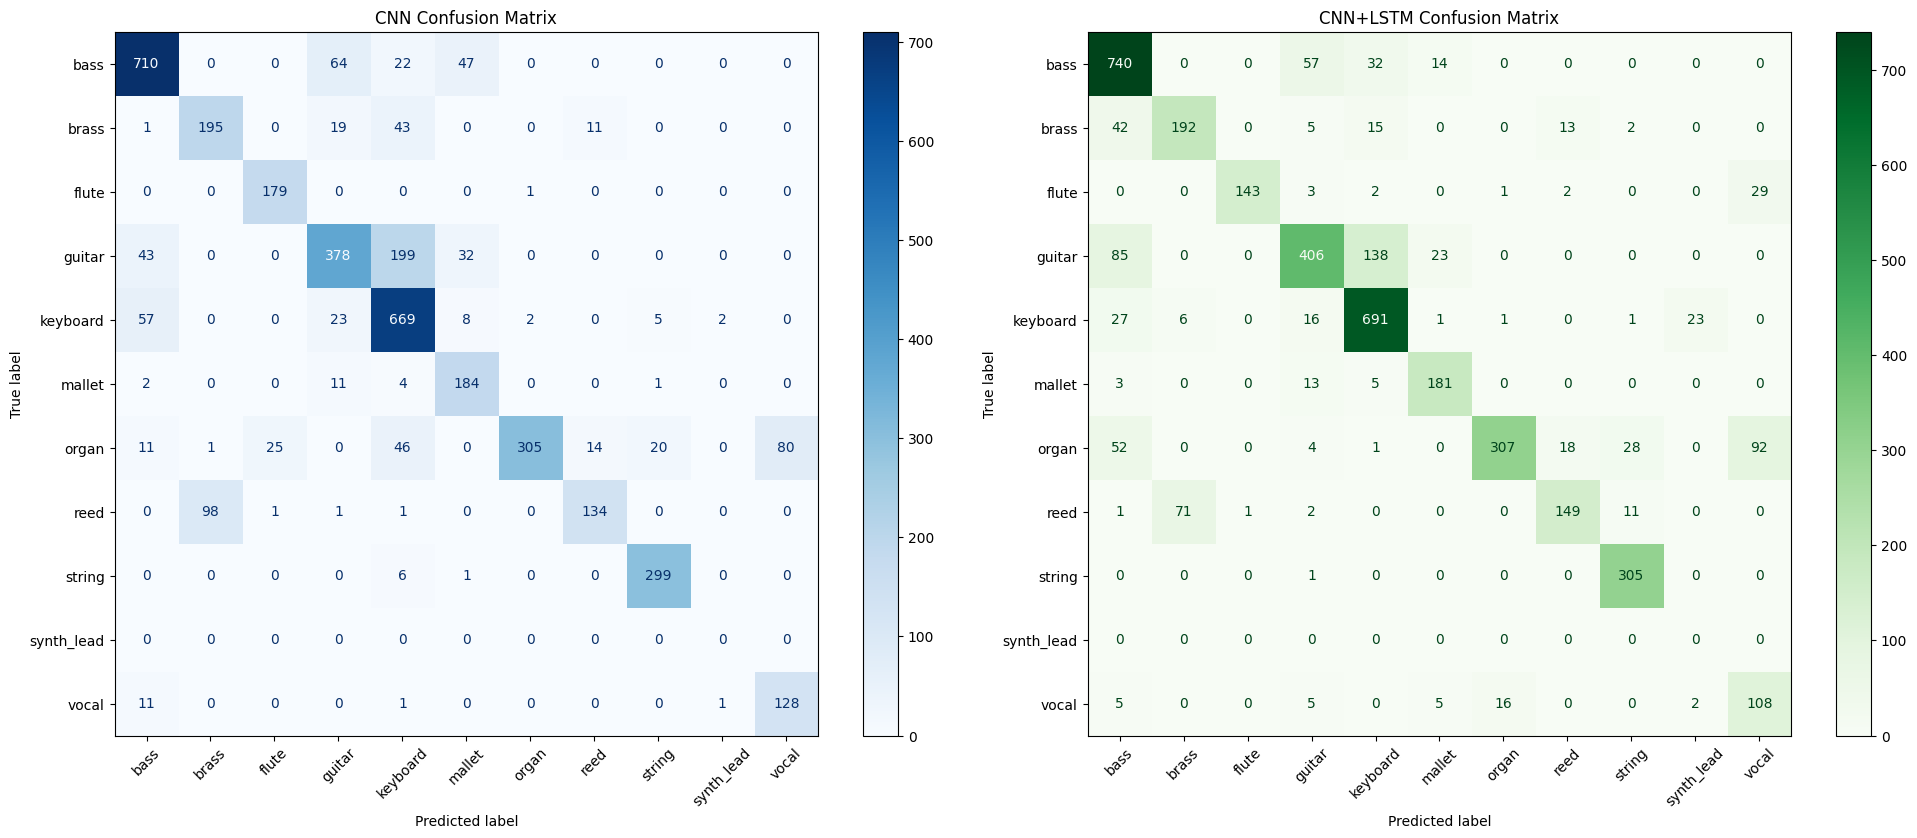


Confusion Matrix Interpretation:
- Darker diagonal = better performance
- Off-diagonal values show common misclassifications
- Similar-sounding instruments may be confused (e.g., reed vs brass)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_cnn = confusion_matrix(cnn_labels, cnn_preds)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=le.classes_)
disp_cnn.plot(ax=axes[0], cmap="Blues", xticks_rotation=45)
axes[0].set_title("CNN Confusion Matrix")

cm_cnnlstm = confusion_matrix(cnnlstm_labels, cnnlstm_preds)
disp_cnnlstm = ConfusionMatrixDisplay(confusion_matrix=cm_cnnlstm, display_labels=le.classes_)
disp_cnnlstm.plot(ax=axes[1], cmap="Greens", xticks_rotation=45)
axes[1].set_title("CNN+LSTM Confusion Matrix")

plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print("- Darker diagonal = better performance")
print("- Off-diagonal values show common misclassifications")
print("- Similar-sounding instruments may be confused (e.g., reed vs brass)")

### 8.4 Porównanie modeli i wzorce błędów (Rys. 5–6)

Macierze konfuzji ujawniają trzy powtarzające się wzorce błędów, zgodne z intuicją akustyczną: gitara jest często mylona z klawiszowymi (199 przypadków dla CNN, 138 dla CNN+LSTM), brass z reed (98 i 71) oraz organ z wokalem (80 i 92) — wszystkie te pary mają zbliżoną strukturę harmoniczną dźwięku ciągłego, co utrudnia ich rozróżnienie na podstawie samego melspektrogramu pojedynczej nuty.

Zbiorcze porównanie potwierdza, że przejście od klasycznego uczenia maszynowego do uczenia głębokiego przynosi wzrost dokładności z 57,5% do 77,7% dla CNN (ponad 20 punktów procentowych). Dodanie warstwy LSTM daje znacznie mniejszy przyrost — do 78,7%, czyli ok. 1 punkt procentowy względem samego CNN — przy ponaddwukrotnie większej liczbie parametrów i dłuższym czasie treningu. Uwaga: wartość 57,5% dla baseline'u RF pochodzi ze zbioru walidacyjnego (zgodnie z kodem notebooka, gdzie RF jest scorowany na `X_val_mfcc`), natomiast 77,7% i 78,7% to dokładności na zbiorze testowym — porównanie ma więc charakter wskazujący, a nie ścisły.

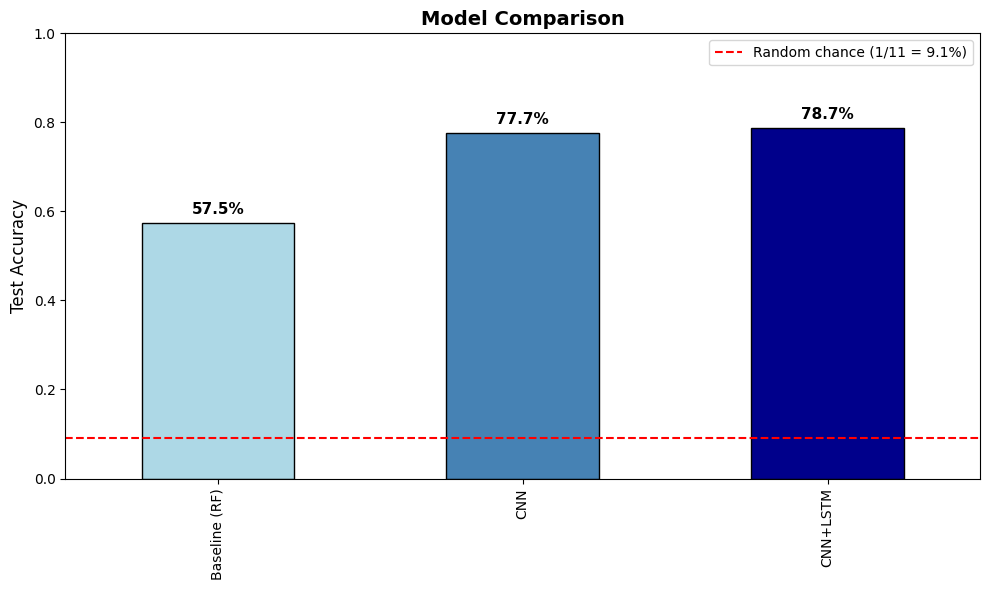


Key Takeaways:
1. Random Forest baseline: 57.5%
2. CNN improves to: 77.7%
3. CNN+LSTM achieves: 78.7%

Improvement over baseline: 21.2%


In [21]:
results = {
    "Baseline (RF)": rf_accuracy,
    "CNN": (cnn_preds == cnn_labels).mean(),
    "CNN+LSTM": (cnnlstm_preds == cnnlstm_labels).mean(),
}

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["lightblue", "steelblue", "darkblue"]
bars = pd.Series(results).plot.bar(ax=ax, color=colors, edgecolor="black")
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title("Model Comparison", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1)
ax.axhline(y=1/11, color="red", linestyle="--", label="Random chance (1/11 = 9.1%)")
ax.legend()

for i, (model, acc) in enumerate(results.items()):
    ax.text(i, acc + 0.02, f"{acc:.1%}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nKey Takeaways:")
print(f"1. Random Forest baseline: {rf_accuracy:.1%}")
print(f"2. CNN improves to: {results['CNN']:.1%}")
print(f"3. CNN+LSTM achieves: {results['CNN+LSTM']:.1%}")
print(f"\nImprovement over baseline: {results['CNN+LSTM'] - rf_accuracy:.1%}")

### 7.5 Inferencja: klasyfikacja nowych nagrań (Rys. 7)

Do praktycznego zastosowania wytrenowanego modelu zaimplementowano funkcję `predict_instrument()`. Wczytuje ona wskazany plik audio (przez `librosa`), przycina lub dopełnia go do długości 4 s, oblicza melspektrogram dokładnie tak samo jak w treningu i zwraca pięć najbardziej prawdopodobnych rodzin instrumentów wraz z poziomem ufności (softmax).

Poniższy przykład pokazuje działanie dla nagrania `bass_synthetic_068-049-025.wav`: model CNN+LSTM poprawnie wskazał klasę bass z ufnością 91,4%, a kolejne najbardziej prawdopodobne klasy (flute 1,0%, vocal 0,9%, synth_lead 0,9%, brass 0,9%) uzyskały ufność rzędu 1% lub mniej — co świadczy o wysokiej pewności i poprawności predykcji dla tego przykładu. Funkcja obsługuje również pliki spoza zbioru NSynth, co pozwala na testowanie modelu na własnych nagraniach.

Classifying: bass_synthetic_068-049-025.wav



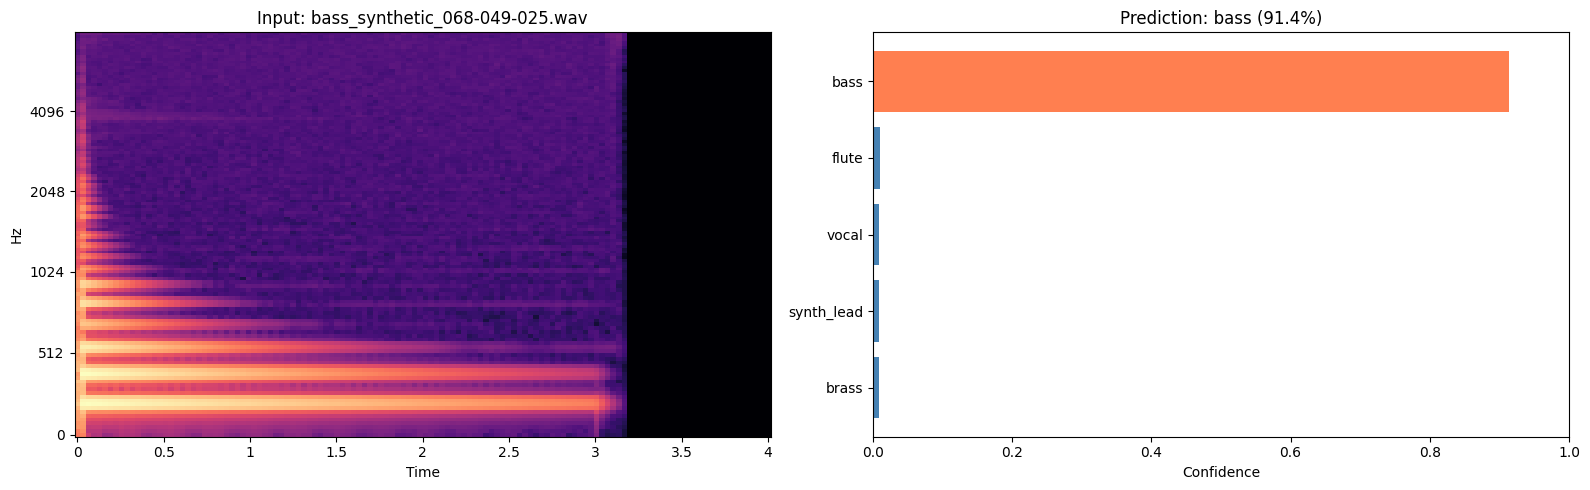


Top predictions:
  bass         91.4%
  flute        1.0%
  vocal        0.9%
  synth_lead   0.9%
  brass        0.9%


[{'family': 'bass', 'confidence': 0.9140893220901489},
 {'family': 'flute', 'confidence': 0.009985438548028469},
 {'family': 'vocal', 'confidence': 0.009352666325867176},
 {'family': 'synth_lead', 'confidence': 0.008921160362660885},
 {'family': 'brass', 'confidence': 0.008879272267222404}]

In [22]:
@torch.no_grad()
def predict_instrument(
    audio_path: str | Path,
    model: nn.Module,
    top_k: int = 5,
    audio: np.ndarray | None = None,
) -> list[dict]:
    """Predict instrument family for a given audio file."""
    model.eval()
    if audio is None:
        audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE)

    target_len = int(SAMPLE_RATE * NOTE_DURATION)
    if len(audio) > target_len:
        audio = audio[:target_len]
    elif len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))

    mel = extract_mel_spectrogram(audio, device)
    mel_tensor = torch.from_numpy(mel).float().unsqueeze(0).unsqueeze(0).to(device)

    logits = model(mel_tensor)
    probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    top_indices = np.argsort(probs)[::-1][:top_k]
    predictions = []
    for idx in top_indices:
        predictions.append(
            {
                "family": le.classes_[idx],
                "confidence": float(probs[idx]),
            }
        )
    return predictions


def visualize_prediction(audio_path: str | Path, model: nn.Module, top_k: int = 5):
    """Predict and visualize instrument classification for an audio file."""
    audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE)
    predictions = predict_instrument(audio_path, model, top_k=top_k, audio=audio)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    mel_db = extract_mel_spectrogram(audio, device)
    librosa.display.specshow(
        mel_db,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        ax=axes[0],
        cmap="magma",
    )
    axes[0].set_title(f"Input: {Path(audio_path).name}")

    families = [p["family"] for p in predictions]
    confidences = [p["confidence"] for p in predictions]
    colors = ["steelblue" if i > 0 else "coral" for i in range(len(families))]
    axes[1].barh(families[::-1], confidences[::-1], color=colors[::-1])
    axes[1].set_xlabel("Confidence")
    top = predictions[0]
    axes[1].set_title(f"Prediction: {top['family']} ({top['confidence']:.1%})")
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

    print("\nTop predictions:")
    for p in predictions:
        print(f"  {p['family']:12s} {p['confidence']:.1%}")

    return predictions


sample_path = TEST_DIR / "audio" / f"{df_test.iloc[0]['note_str']}.wav"
print(f"Classifying: {sample_path.name}\n")
visualize_prediction(sample_path, cnnlstm_model)

### 7.6 Interaktywny widget

Wytrenowany model udostępniono również przez prosty interfejs interaktywny zbudowany z ipywidgets: pole tekstowe ze ścieżką do pliku audio, przycisk „Classify" oraz obszar wyniku z wbudowanym odtwarzaczem Audio. Pozwala to sklasyfikować dowolne nagranie — w tym pliki spoza zbioru NSynth — bez opuszczania środowiska notebooka i bez ponownego trenowania modelu, co demonstruje gotowość potoku do praktycznego użycia i szybkiego eksperymentowania z własnymi danymi.

In [ ]:
import ipywidgets as widgets
from IPython.display import Audio, display

file_input = widgets.Text(
    value=str(TEST_DIR / "audio" / f"{df_test.iloc[0]['note_str']}.wav"),
    description="Audio path:",
    layout=widgets.Layout(width="80%"),
)
classify_btn = widgets.Button(description="Classify", button_style="primary")
output = widgets.Output()


def on_classify(btn):
    output.clear_output()
    with output:
        path = Path(file_input.value)
        if not path.exists():
            print(f"File not found: {path}")
            return
        display(Audio(filename=str(path)))
        visualize_prediction(path, cnnlstm_model)


classify_btn.on_click(on_classify)
display(widgets.VBox([file_input, classify_btn, output]))

## 9. Wnioski

Wyniki projektu jednoznacznie potwierdzają przewagę podejścia opartego na melspektrogramie i sieciach konwolucyjnych nad klasycznym uczeniem maszynowym na uśrednionych cechach MFCC — obserwacja zgodna z przywołaną literaturą (Han i in., 2017; Senatori i in., 2025; Chen i in., 2024). Różnica ponad 20 punktów procentowych między baseline'em a CNN wskazuje, że zachowanie pełnej struktury czasowo-częstotliwościowej sygnału, a nie tylko jej uśrednionych statystyk, jest istotne dla rozróżniania barwy jedenastu rodzin instrumentów.

Dodanie warstwy LSTM do CNN przyniosło jedynie marginalny przyrost dokładności (ok. 1 punkt procentowy na zbiorze testowym, a zaledwie ok. 0,4 punktu na walidacyjnym — blisko szumu pomiarowego), kosztem ponaddwukrotnie większej liczby parametrów, dłuższego treningu i wyraźniejszego przeuczenia. Może to wynikać z tego, że dla nagrań tak krótkich i ustandaryzowanych jak pojedyncza nuta NSynth znaczna część informacji o ewolucji czasowej jest już pośrednio uchwycona przez wymiar czasowy melspektrogramu przetwarzany przez warstwy konwolucyjne, co ogranicza dodatkową wartość jawnego modelowania sekwencyjnego. Nie wyklucza to przydatności architektur rekurencyjnych lub uwagowych w zadaniach o dłuższym kontekście czasowym, takich jak rozpoznawanie instrumentu we frazie muzycznej, a nie w pojedynczej nucie.

Głównym ograniczeniem wytrenowanych modeli jest mylenie instrumentów o zbliżonej charakterystyce akustycznej (gitara/klawisze, brass/reed, organ/wokal) — błędy te są trudne do usunięcia bez wzbogacenia reprezentacji wejściowej (np. o cechy harmoniczne) lub wykorzystania większego kontekstu nagrania. Drugim istotnym ograniczeniem jest niezbalansowanie zbioru danych, w szczególności całkowita nieobecność klasy `synth_lead` w podzbiorach walidacyjnym i testowym, co uniemożliwia rzetelną ocenę modelu dla tej klasy i powinno zostać skorygowane przed jakimkolwiek wdrożeniem produkcyjnym.

Z inżynierskiego punktu widzenia kluczowym wnioskiem jest istotność cache'owania cech w plikach memory-mapped — bez tego kroku iteracyjne eksperymentowanie z architekturą i hiperparametrami byłoby znacząco utrudnione ze względu na czas ekstrakcji melspektrogramów. Naturalnymi kierunkami dalszego rozwoju projektu, częściowo wskazanymi już w samym notebooku, są: augmentacja danych (przesunięcie wysokości dźwięku, rozciąganie w czasie, dodawanie szumu), zastosowanie bardziej zaawansowanych architektur (ResNet, transformery), wykorzystanie modeli wstępnie wytrenowanych na dużych zbiorach audio (np. AudioSet) w trybie transfer learning, a także zrównoważenie klas oraz uzupełnienie zbioru walidacyjnego i testowego o przykłady klasy `synth_lead`.